# Building a Multimodal RAG Pipeline

Code companion for the article.

> **Setup:** activate the pixi env with `pixi shell`, then add your `ANTHROPIC_API_KEY` to `.env`.

## Imports

In [1]:
import os
import base64
from io import BytesIO
from typing import List, Tuple, Optional

import clip
import torch
import numpy as np
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt

from datasets import load_dataset
from pymilvus import MilvusClient, DataType
from anthropic import Anthropic
from dotenv import load_dotenv

# Pull ANTHROPIC_API_KEY out of a .env file so we never hardcode the key.
load_dotenv(dotenv_path="../.env")

/Users/rubenwinastwan/miniforge3/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

## From raw images to embeddings

CLIP maps both text and images into the same 512-dimensional vector space.

In [2]:
class CLIPEmbedder:
    def __init__(self, model_name: str = "ViT-B/32"):
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.model, self.preprocess = clip.load(model_name, device=self.device)

    def encode_image(self, image: Image.Image) -> torch.Tensor:
        preprocessed = self.preprocess(image).unsqueeze(0).to(self.device)
        return self.model.encode_image(preprocessed)

    def encode_text(self, text: str) -> torch.Tensor:
        tokens = clip.tokenize(text).to(self.device)
        return self.model.encode_text(tokens)

    def encode_multimodal(self, text: str, image: Image.Image) -> np.ndarray:
        text_embedding = self.encode_text(text)
        image_embedding = self.encode_image(image)
        # Fuse by averaging the two embeddings
        return np.mean([
            image_embedding.detach().cpu().numpy(),
            text_embedding.detach().cpu().numpy(),
        ], axis=0)

## Storing embeddings in a vector database

Milvus Lite stores embeddings in a local file — no server required. We use an IVF-FLAT index with cosine similarity.

In [3]:
class MilvusDatabase:
    """
    Manages Milvus database operations.
    """

    def __init__(self, db_path: str = "./food_tiny.db", collection_name: str = "food_tiny"):
        self.client = MilvusClient(db_path)
        self.collection_name = collection_name
        # Don't automatically setup collection - let it be called explicitly when needed

    def setup_collection(self):
        """
        Initialize the Milvus collection with proper schema and indexes.
        """
        if self.client.has_collection(self.collection_name):
            self.client.drop_collection(self.collection_name)

        # Prepare index parameters
        # Note: milvus-lite local mode supports FLAT, HNSW, AUTOINDEX (not IVF_FLAT)
        index_params = self.client.prepare_index_params()
        index_params.add_index(
            field_name="embedding",
            index_type="HNSW",
            metric_type="COSINE",
            params={"M": 8, "efConstruction": 64}
        )

        # Create schema
        schema = self.client.create_schema(
            auto_id=True,
            enable_dynamic_field=True
        )
        schema.add_field(field_name="id", datatype=DataType.INT64, is_primary=True, auto_id=True)
        schema.add_field(field_name="embedding", datatype=DataType.FLOAT_VECTOR, dim=512)
        schema.add_field(field_name="filename", datatype=DataType.VARCHAR, max_length=500)

        # Create collection
        self.client.create_collection(
            collection_name=self.collection_name,
            schema=schema,
            index_params=index_params
        )

    def insert_image_data(self, filename: str, embedding: List[float]):
        """
        Insert image data into the collection.
        """
        image_data = {
            "filename": filename,
            "embedding": embedding
        }
        self.client.insert(collection_name=self.collection_name, data=image_data)

    def search_similar(self, query_embedding: List[float], limit: int = 4) -> List[dict]:
        """
        Search for similar images in the database.
        """
        results = self.client.search(
            collection_name=self.collection_name,
            data=[query_embedding],
            limit=limit,
            output_fields=["filename"],
        )[0]
        return results

The ingestion pipeline loops over the dataset, embeds each image, and inserts it along with the image path into Milvus.

In [4]:
class DatasetProcessor:
    """
    Handles dataset loading and processing.
    """

    def __init__(self, embedder: CLIPEmbedder, database: MilvusDatabase, save_dir: str = "./food_images/"):
        self.embedder = embedder
        self.database = database
        self.save_dir = save_dir
        os.makedirs(save_dir, exist_ok=True)

    def process_food_dataset(self, dataset_name: str = "ruben3010/food101-tiny"):
        """
        Process the food dataset and populate the database.
        """
        food_dataset = load_dataset(dataset_name)
        image_uuid = 0

        for img in tqdm(food_dataset["train"]["image"]):
            image_uuid += 1
            file_path = f"{self.save_dir}{image_uuid}.jpg"

            # Generate embedding
            image_embedding = self.embedder.encode_image(img)

            # Save image
            img.save(file_path)

            # Insert into database
            self.database.insert_image_data(file_path, image_embedding.tolist()[0])

Wire it all together and run the ingestion once.

In [5]:
embedder = CLIPEmbedder()
database = MilvusDatabase()
database.setup_collection()

processor = DatasetProcessor(embedder, database)
processor.process_food_dataset()

100%|███████████████████████████████████████████████████████████████████████████████| 2000/2000 [01:35<00:00, 20.87it/s]


## Augmenting the prompt and generating the answer

A small helper to convert images to the base64 strings the API expects.

In [6]:
class ImageProcessor:
    """
    Small helpers for moving images in and out of the API.
    """

    @staticmethod
    def load_image(path: str) -> Image.Image:
        return Image.open(path).convert("RGB")

    @staticmethod
    def image_to_base64(image: Image.Image) -> str:
        if image.mode != "RGB":
            image = image.convert("RGB")
        buffered = BytesIO()
        image.save(buffered, format="JPEG")
        return base64.b64encode(buffered.getvalue()).decode("utf-8")

In [7]:
class RAGProcessor:
    """
    Handles RAG (Retrieval-Augmented Generation) operations.
    """

    def __init__(self):
        # Anthropic() picks up ANTHROPIC_API_KEY from the environment (loaded via load_dotenv()).
        self.client = Anthropic()

    def generate_response(self, user_prompt: str, user_image: Image.Image,
                          context_images: List[Image.Image]) -> str:
        """
        Generate response using the Anthropic API with image context.
        """
        context_image_base64_list = [ImageProcessor.image_to_base64(img) for img in context_images]

        if user_image is not None:

            user_image_base64 = ImageProcessor.image_to_base64(user_image)
            prompt_with_context = (
                f"User Prompt: {user_prompt}\n\n"
                f"Instructions: Use the 'User Image' as the primary reference for answering the query. "
                f"Use the 'Database Images' as contexts to inform and help you formulate the response. "
                f"Below your main response, the 'Database Images' will be displayed to the user. So always be aware of their existence with sentence like 'as you can see in the images below' or any other variations, depending on the user's query. "
                f"The images are provided below, with the 'User Image' first, followed by {len(context_images)} 'Database Images'."
            )

            content = [
                {"type": "text", "text": prompt_with_context},
                {"type": "image", "source": {"type": "base64", "media_type": "image/jpeg", "data": user_image_base64}},
                *[
                    {"type": "image", "source": {"type": "base64", "media_type": "image/jpeg", "data": img_base64}}
                    for img_base64 in context_image_base64_list
                ],
            ]
        else:

            prompt_with_context = (
                f"User Prompt: {user_prompt}\n\n"
                f"Instructions: Use the 'Database Images' provided below to inform and help you formulate the response to the user's query. "
                f"All images shown are from the database and represent similar or relevant content based on the user's text prompt. "
                f"Below your main response, these 'Database Images' will be displayed to the user. So always be aware of their existence with sentence like 'as you can see in the images below' or any other variations, depending on the user's query. "
                f"There are {len(context_images)} 'Database Images' provided below."
            )

            content = [
                {"type": "text", "text": prompt_with_context},
                *[
                    {"type": "image", "source": {"type": "base64", "media_type": "image/jpeg", "data": img_base64}}
                    for img_base64 in context_image_base64_list
                ],
            ]

        response = self.client.messages.create(
            model="claude-sonnet-4-6",
            max_tokens=1000,
            messages=[{"role": "user", "content": content}],
        )
        return response.content[0].text

## Putting everything together: ask a question, get an answer

In [8]:
def load_context_images(image_paths: List[str]) -> List[Image.Image]:
    """
    Load context images from file paths.
    """
    context_images = []
    for image_path in image_paths:
        if not os.path.exists(image_path):
            print(f"Error: Image not found at {image_path}")
            continue
        img = Image.open(image_path)
        context_images.append(img)
    return context_images

def display_images(images: List[Image.Image], figsize: Tuple[int, int] = (15, 5)):
    """
    Display a list of images in a horizontal layout.
    """
    fig, axes = plt.subplots(1, len(images), figsize=figsize)

    # Handle case where there's only one image
    if len(images) == 1:
        axes = [axes]

    for i, img in enumerate(images):
        axes[i].imshow(img)
        axes[i].set_title(f'Image {i+1}')
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

def search_and_respond(rag_processor, user_text_prompt: str = "", user_image_path: str = "") -> Optional[str]:
    """
    Perform search and generate response based on the mode.
    """

    if not user_text_prompt and not user_image_path:
        raise ValueError("Either user_text_prompt or user_image_path must be provided")

    user_image = None
    if user_image_path:
        try:
            user_image = ImageProcessor.load_image(user_image_path)
        except:
            user_image = Image.open(user_image_path)

    # Generate query embedding based on available inputs
    if user_text_prompt and user_image_path:
        query_embedding = embedder.encode_multimodal(user_text_prompt, user_image)
    elif user_text_prompt:
        query_embedding = embedder.encode_text(user_text_prompt).detach().cpu().numpy()
    elif user_image_path:
        query_embedding = embedder.encode_image(user_image).detach().cpu().numpy()

    # Search for similar images
    search_results = database.search_similar(query_embedding.tolist()[0])
    image_paths = [item["entity"]["filename"] for item in search_results]
    context_images = load_context_images(image_paths)

    # Generate response
    if not user_text_prompt:
        raise ValueError("Text prompt is required for RAG")

    response = rag_processor.generate_response(
        user_text_prompt, user_image, context_images
    )
    print(response)
    display_images(context_images)
    return response, context_images

# Side Dishes and Condiments for Steak

Steak is a versatile dish that pairs wonderfully with a wide variety of sides and condiments. Here's a breakdown of popular options:

## 🥣 Condiments & Sauces
- **Au jus** – a classic thin beef dripping sauce (visible in the images below)
- **Horseradish cream sauce** – a creamy, tangy accompaniment
- **Mustard-based sauces** – adding a spicy, tangy kick
- **Béarnaise or hollandaise sauce**
- **Peppercorn sauce**
- **Steak sauce (A1-style)**

## 🥔 Starchy Sides
- **Baked potato** – often topped with butter, sour cream, or chives, a steakhouse staple clearly visible in the images below
- **Mashed potatoes** – creamy and buttery
- **French fries or steak fries**
- **Loaded potato skins**

## 🥦 Vegetable Sides
- **Sautéed or roasted mixed vegetables** – such as zucchini, carrots, bell peppers, and onions, as you can see in the images below
- **Sautéed mushrooms** – a rich, earthy complement to steak
- **Steamed broccoli or asparagus**
- **Creamed sp

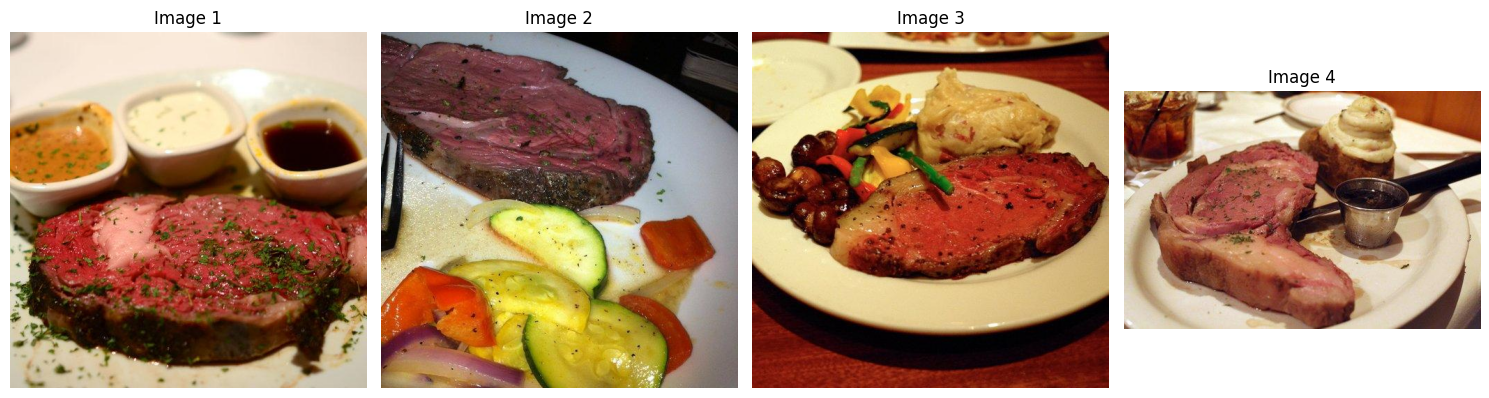

In [12]:
rag_processor = RAGProcessor()
user_text_prompt = "What kinds of side dishes and condiments do people eat with a steak?"
user_image_path = ""

response, context = search_and_respond(rag_processor, user_text_prompt, user_image_path)